In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon')
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon\raman_simulation')
import useful_funcs
import simulation as s
from matplotlib.colors import TwoSlopeNorm
import scienceplots
import matplotlib.colors as colors
import matplotlib.ticker as ticker

In [3]:
sim = s.sim()
sim.ls_order = 2
sim.get_f()

sim.w0r = 31.52*1e-6
sim.r_sp = .0755
sim.r_pi = .0016
sim.w0b = 30.0*1e-6
sim.b_sp = .3355
sim.b_pi = .329

In [8]:
P_bank = np.linspace(4, 540, 20)*1e-3
sim.power_scaling(P_bank)

power scan progress:   0%|          | 0/20 [00:00<?, ?it/s]

spectroscopy, Pb = 4.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 32.21 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 60.42 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 88.63 mW:   0%|          | 0/40 [00:00<?, ?it/s]

...

spectroscopy, Pb = 427.16 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 455.37 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 483.58 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 511.79 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 540.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

In [10]:
inf_int = np.array(())

for i in range(len(sim.flop_fits)):
    inf_int = np.append(inf_int, 1-max(sim.flop_fits[i][1]))

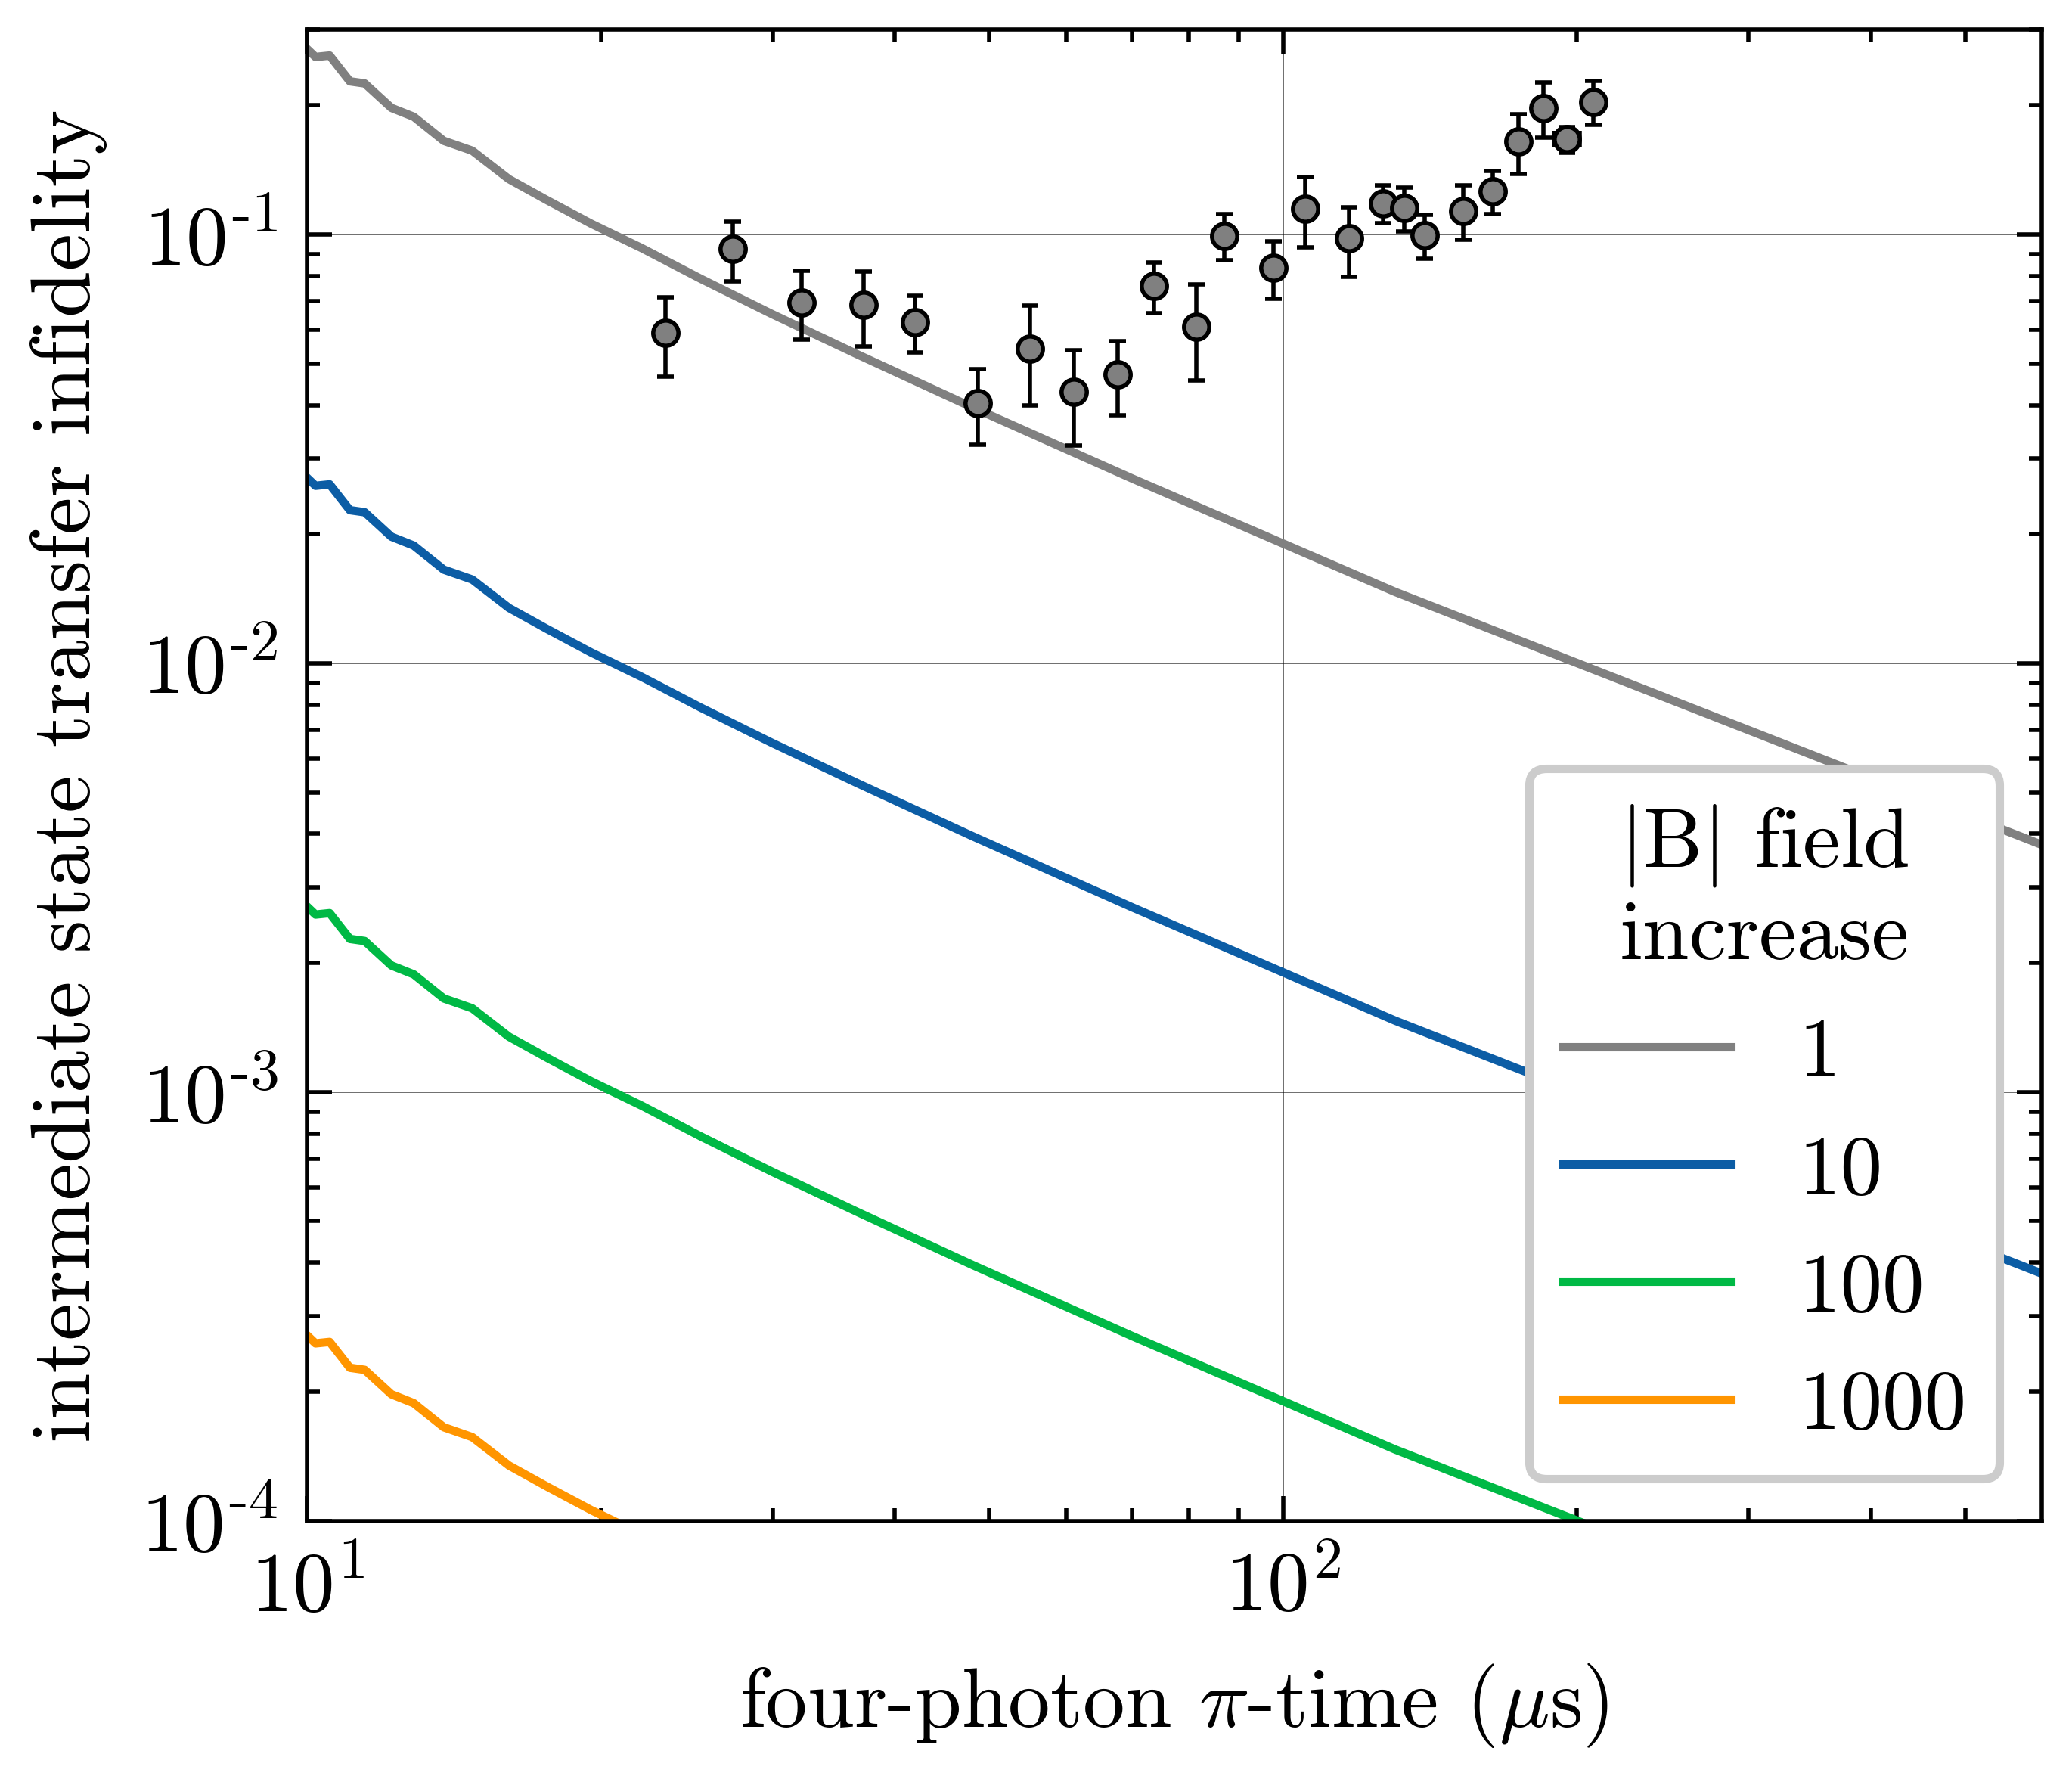

In [11]:
f1 = 10
f2 = 100
f3 = 1000
f4 = 10000


inf_int1 = inf_int/f1
inf_int2 = inf_int/f2
inf_int3 = inf_int/f3
inf_int4 = inf_int/f4

outline = 'black'
cscat = 'grey'
    
with plt.style.context(['science','no-latex']):
    plt.figure(figsize = (3.7,3.2), dpi = 800)
    plt.plot(np.pi/sim.Ω_num_bank*1e6, inf_int, color = cscat, label = '1')
    plt.plot(np.pi/sim.Ω_num_bank*1e6, inf_int1, label = str(f1))
    plt.plot(np.pi/sim.Ω_num_bank*1e6, inf_int2, label = str(f2))
    plt.plot(np.pi/sim.Ω_num_bank*1e6, inf_int3, label = str(f3))
    #plt.plot(sim4.Ω4_num_bank*1e6, inf_int4, label = str(f4))

    plt.errorbar(sim.tpi_4*1e6, 1-sim.fid_4, yerr = sim.δfid_4,xerr = sim.δtpi_4*1e6, marker = 'o',
                 ecolor = outline, markeredgecolor = outline, markeredgewidth = .5, 
                 ls='none', markersize=3, capsize=1, elinewidth = .5,markerfacecolor=cscat, zorder = 3)

    plt.legend(title=r"$|$B$|$ field" + "\n" + "increase",frameon=True, framealpha=1)

    plt.grid(color = 'black',linewidth = 0.05)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(r'four-photon $\pi$-time ($\mu$s)')
    plt.ylabel('intermediate state transfer infidelity')
    plt.xlim(10,599)
    plt.ylim(1e-4, .3)
    plt.show()